In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from matplotlib_venn import venn2,venn3

import _helper_grammar_functions as ga
from _helper_functions import *

In [8]:

rep2setlist={}
rep2df={}
for rep in [1,2,3]:
    
    fn=f'F05xi-Syntax-Features-By-Reps/5-rep{rep}-stats-sig-motifs-possible-realData_filtMotifs=ord_ori_spc_2-3mer_minenrichFUNC=0.1_minN=50.pandas.df.pickle'

    df=pd.read_pickle(fn)

    rep2df[rep]=df.copy(deep=True).set_index('phrase',drop=True)

    rep2setlist[rep]=set(df['phrase'])


In [9]:
rep2df[rep].head()

,phrase-type,phrase-length,phrase-is-spacing,real-data,hyp-func-p,func-enrich,func-odds-ratio,hyp-func-p-bonf
phrase,,,,,,,,
"(g, 21, e, 24, E)",parse_ord_ori_spc,3,True,"(11, 50, 3)",5.492420e-06,4.452878,5.172610,1.774601e-02
"(g, 13, e, 24, E)",parse_ord_ori_spc,3,True,"(24, 101, 15)",1.774430e-10,4.441312,5.160043,5.733183e-07
"(g, 13, e, 32, E)",parse_ord_ori_spc,3,True,"(44, 204, 26)",3.300498e-16,4.160354,4.776150,1.066391e-12
"(g, 15, E, 22, E)",parse_ord_ori_spc,3,True,"(22, 110, 14)",1.137233e-08,3.903893,4.424182,3.674400e-05
"(e, 36, g, 9, E)",parse_ord_ori_spc,3,True,"(18, 94, 10)",2.476244e-07,3.822441,4.314965,8.000744e-04


In [13]:
alldf=pd.read_pickle('F05-Syntax-Features/5-stats-sig-motifs-possible-realData_filtMotifs=ord_ori_spc_minenrichFUNC=0.1_minN=50.pandas.df.pickle')
rep2setlist['all']=set(alldf['phrase'])
alldf.head()

,phrase,phrase-type,phrase-length,phrase-is-spacing,real-data,hyp-func-p,func-enrich,func-odds-ratio,hyp-func-p-bonf
phrase-key,,,,,,,,,
ord_ori_spc=g_21_e_24_E,"(g, 21, e, 24, E)",parse_ord_ori_spc,3,True,"(63, 34, 7)",1.042766e-32,5.018826,11.206427,3.246130e-29
ord_ori_spc=g_13_e_24_E,"(g, 13, e, 24, E)",parse_ord_ori_spc,3,True,"(108, 73, 21)",1.030567e-46,4.429628,8.385350,3.208155e-43
ord_ori_spc=g_36_g_9_E,"(g, 36, g, 9, E)",parse_ord_ori_spc,3,True,"(162, 108, 42)",2.617632e-66,4.301851,7.889255,8.148688e-63
ord_ori_spc=g_15_E_22_E,"(g, 15, E, 22, E)",parse_ord_ori_spc,3,True,"(107, 85, 25)",6.657682e-42,4.085253,7.098879,2.072536e-38
ord_ori_spc=e_24_E_8_G,"(e, 24, E, 8, G)",parse_ord_ori_spc,3,True,"(105, 80, 29)",6.524524e-41,4.065093,7.029848,2.031084e-37


# reproducibility of discovery 

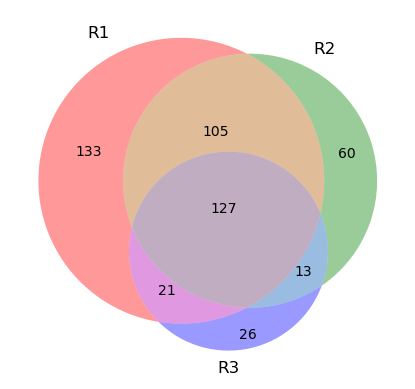

In [16]:
venn3(
    subsets=[rep2setlist[rep] for rep in [1,2,3]],
    set_labels=('R1', 'R2', 'R3'),
    set_colors=('r', 'g', 'b'),
    alpha=0.4,
    normalize_to=1.0,
    ax=None,
    subset_label_formatter=None)

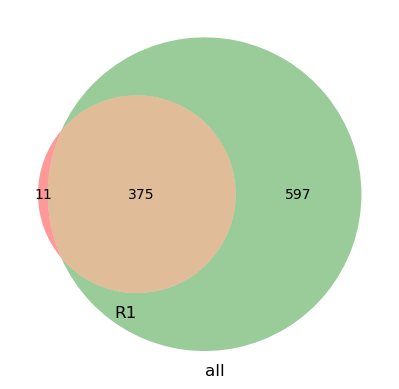

In [17]:
venn2(
    subsets=[rep2setlist[rep] for rep in [1,'all']],
    set_labels=('R1', 'all'),
    set_colors=('r', 'g', 'b'),
    alpha=0.4,
    normalize_to=1.0,
    ax=None,
    subset_label_formatter=None)

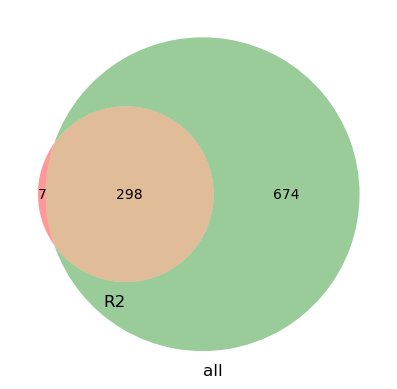

In [18]:
venn2(
    subsets=[rep2setlist[rep] for rep in [2,'all']],
    set_labels=('R2', 'all'),
    set_colors=('r', 'g', 'b'),
    alpha=0.4,
    normalize_to=1.0,
    ax=None,
    subset_label_formatter=None)

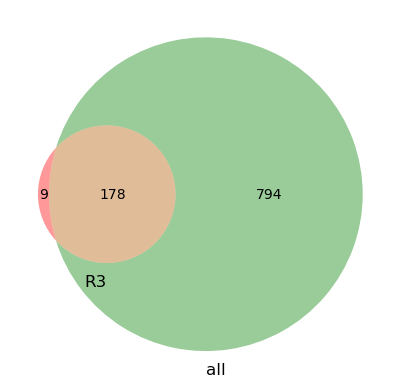

In [19]:
venn2(
    subsets=[rep2setlist[rep] for rep in [3,'all']],
    set_labels=('R3', 'all'),
    set_colors=('r', 'g', 'b'),
    alpha=0.4,
    normalize_to=1.0,
    ax=None,
    subset_label_formatter=None)

# reproducibilty of effect sizes

In [22]:
sharedFeats=rep2setlist[1] & rep2setlist[2] & rep2setlist[3]


In [23]:
comp2rep2data={}

for r1,r2 in [(1,2),(1,3),(2,3)]:

    
    comparison=(r1,r2)
    if comparison not in comp2rep2data:
        comp2rep2data[comparison]={r1:[],r2:[]}
        
    sharedFeats=rep2setlist[r1]&rep2setlist[r2]

    for ri in [r1,r2]:
        for feat in sharedFeats :
            OR=rep2df[ri].at[feat,'func-odds-ratio']
            comp2rep2data[comparison][ri].append(OR)    

In [32]:
sharedFeats=list(sharedFeats)

rep2orlist={}
for rep in [1,2,3]:
    rep2orlist[rep]=[]
    for feat in sharedFeats:

        if feat in rep2df[rep].index or ga.motif_revcomp(feat,'ord_ori_spc') in rep2df[rep].index:
            OR=rep2df[rep].at[feat,'func-odds-ratio']
            rep2orlist[rep].append(OR)
        


Text(0.5, 1.0, 'effect size of syntax features\npearson=0.832')

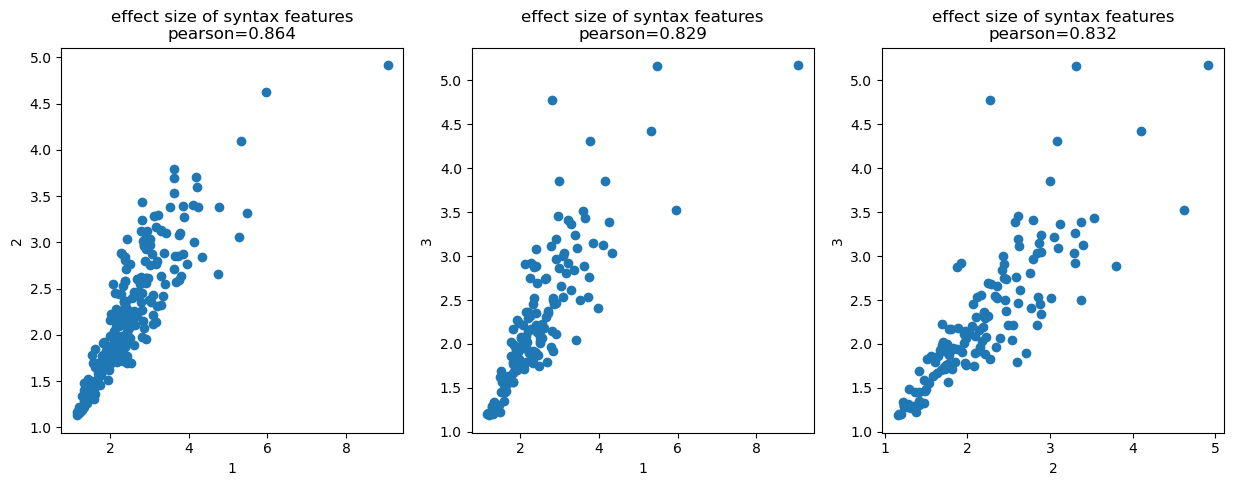

In [36]:
fig,ax=plt.subplots(1,3,figsize=(15,5))

d1=rep2orlist[1]
d2=rep2orlist[2]
d3=rep2orlist[3]

ax[0].scatter(comp2rep2data[1,2][1],comp2rep2data[1,2][2])
ax[1].scatter(comp2rep2data[1,3][1],comp2rep2data[1,3][3])
ax[2].scatter(comp2rep2data[2,3][2],comp2rep2data[2,3][3])

pears12=round(stats.pearsonr(comp2rep2data[1,2][1],comp2rep2data[1,2][2])[0],3)
pears13=round(stats.pearsonr(comp2rep2data[1,3][1],comp2rep2data[1,3][3])[0],3)
pears23=round(stats.pearsonr(comp2rep2data[2,3][2],comp2rep2data[2,3][3])[0],3)

ax[0].set_ylabel('2')
ax[1].set_ylabel('3')
ax[2].set_ylabel('3')

ax[0].set_xlabel('1')
ax[1].set_xlabel('1')
ax[2].set_xlabel('2')

ax[0].set_title(f'effect size of syntax features\npearson={pears12}')
ax[1].set_title(f'effect size of syntax features\npearson={pears13}')
ax[2].set_title(f'effect size of syntax features\npearson={pears23}')
